In [14]:
import pandas as pd
import numpy as np
from pathlib import Path

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline


In [15]:
# ============================================================
# 1. Paths
# ============================================================

INPUT_PATH = Path("../data/processed/neutral_scoring_prepared/neutral_scoring_input_v1.tsv")

OUTPUT_DIR = Path("../results/neutral_scoring_results")
OUTPUT_DIR.mkdir(exist_ok=True)

SCORED_OUTPUT = OUTPUT_DIR / "neutral_deviation_scores_v1.tsv"
THRESHOLD_OUTPUT = OUTPUT_DIR / "neutral_deviation_thresholds_v1.tsv"
ENRICHMENT_OUTPUT = OUTPUT_DIR / "posthoc_group_enrichment_v1.tsv"

# ============================================================
# 2. Load prepared input
# ============================================================

df = pd.read_csv(INPUT_PATH, sep="\t", low_memory=False)

print("Input shape:", df.shape)

print("\nAnalysis group distribution:")
print(df["analysis_group"].value_counts(dropna=False))

# ============================================================
# 3. Define feature sets
# ============================================================

feature_sets = {
    "mlc_only": [
        "mlc_score",
    ],

    "population_only": [
        "gnomad_observed",
        "helix_observed",
        "observed_in_any_population_db",
        "observed_in_both_population_dbs",

        "gnomad_homoplasmic_af",
        "gnomad_heteroplasmic_af",
        "gnomad_combined_af_simple",
        "helix_af_hom",
        "helix_af_het",

        "pop_af_hom_max",
        "pop_af_het_max",
        "pop_af_max",
        "pop_af_hom_sum",
        "pop_af_het_sum",
        "pop_af_sum",

        "log10_gnomad_homoplasmic_af",
        "log10_gnomad_heteroplasmic_af",
        "log10_gnomad_combined_af_simple",
        "log10_helix_af_hom",
        "log10_helix_af_het",
        "log10_pop_af_hom_max",
        "log10_pop_af_het_max",
        "log10_pop_af_max",
        "log10_pop_af_hom_sum",
        "log10_pop_af_het_sum",
        "log10_pop_af_sum",

        "gnomad_max_heteroplasmy",
        "helix_mean_arf",
        "helix_max_arf",
        "pop_max_heteroplasmy_or_arf",
    ],
}

feature_sets["combined_mlc_population"] = (
    feature_sets["mlc_only"] + feature_sets["population_only"]
)

# Remove duplicates
for name in feature_sets:
    feature_sets[name] = list(dict.fromkeys(feature_sets[name]))

Input shape: (49704, 40)

Analysis group distribution:
analysis_group
unlabeled_or_other            41280
neutral_reference              8284
article_pathogenic_posthoc       84
disease_suspected_posthoc        56
Name: count, dtype: int64


In [16]:
# ============================================================
# 5. Neutral-only model function
# ============================================================

def fit_score_isolation_forest(data, feature_cols, score_name):
    neutral_mask = data["analysis_group"] == "neutral_reference"

    X_neutral = data.loc[neutral_mask, feature_cols].copy()
    X_all = data[feature_cols].copy()

    print("\n" + "=" * 80)
    print(score_name)
    print("=" * 80)
    print("Neutral training size:", X_neutral.shape)
    print("All scoring size:", X_all.shape)

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("model", IsolationForest(
            n_estimators=500,
            contamination="auto",
            random_state=42,
            n_jobs=-1,
        )),
    ])

    model.fit(X_neutral)

    # decision_function: higher = more normal
    normality_score = model.decision_function(X_all)

    # We invert it: higher = more anomalous / more neutral-deviating
    deviation_score = -normality_score

    out = pd.Series(
        deviation_score,
        index=data.index,
        name=f"{score_name}_deviation_score",
    )

    return out

In [10]:
# ============================================================
# 6. Compute scores
# ============================================================

scored = df.copy()

for set_name, cols in feature_sets.items():
    scored[f"{set_name}_deviation_score"] = fit_score_isolation_forest(
        scored,
        cols,
        set_name,
    )

    scored[f"{set_name}_rank"] = (
        scored[f"{set_name}_deviation_score"]
        .rank(method="min", ascending=False)
        .astype(int)
    )

    scored[f"{set_name}_percentile"] = (
        scored[f"{set_name}_deviation_score"]
        .rank(method="average", pct=True)
    )



mlc_only
Neutral training size: (8284, 1)
All scoring size: (49704, 1)

population_only
Neutral training size: (8284, 30)
All scoring size: (49704, 30)

combined_mlc_population
Neutral training size: (8284, 31)
All scoring size: (49704, 31)


In [11]:
# ============================================================
# 7. Thresholds based on neutral reference distribution
# ============================================================

threshold_rows = []

neutral_mask = scored["analysis_group"] == "neutral_reference"

for set_name in feature_sets:
    score_col = f"{set_name}_deviation_score"

    neutral_scores = scored.loc[neutral_mask, score_col]

    for q in [0.90, 0.95, 0.99]:
        threshold = neutral_scores.quantile(q)

        threshold_rows.append({
            "score_name": set_name,
            "threshold_name": f"T{int(q * 100)}",
            "neutral_quantile": q,
            "threshold_value": threshold,
            "n_neutral_above_threshold": int((neutral_scores > threshold).sum()),
            "fraction_neutral_above_threshold": float((neutral_scores > threshold).mean()),
        })

        scored[f"{set_name}_above_T{int(q * 100)}"] = (
            scored[score_col] > threshold
        ).astype(int)

threshold_df = pd.DataFrame(threshold_rows)

threshold_df.to_csv(THRESHOLD_OUTPUT, sep="\t", index=False)

print("\nThresholds:")
print(threshold_df)

print("\nSaved thresholds:")
print(THRESHOLD_OUTPUT)


Thresholds:
                score_name threshold_name  neutral_quantile  threshold_value  \
0                 mlc_only            T90              0.90         0.077877   
1                 mlc_only            T95              0.95         0.099567   
2                 mlc_only            T99              0.99         0.224069   
3          population_only            T90              0.90         0.038842   
4          population_only            T95              0.95         0.086591   
5          population_only            T99              0.99         0.161866   
6  combined_mlc_population            T90              0.90         0.039101   
7  combined_mlc_population            T95              0.95         0.075079   
8  combined_mlc_population            T99              0.99         0.157380   

   n_neutral_above_threshold  fraction_neutral_above_threshold  
0                        827                          0.099831  
1                        415                          0.

In [12]:
# ============================================================
# 8. Post-hoc enrichment summaries
# ============================================================

posthoc_groups = [
    "neutral_reference",
    "unlabeled_or_other",
    "article_pathogenic_posthoc",
    "disease_suspected_posthoc",
]

enrichment_rows = []

for set_name in feature_sets:
    for threshold_name in ["T90", "T95", "T99"]:
        flag_col = f"{set_name}_above_{threshold_name}"

        for group in posthoc_groups:
            group_mask = scored["analysis_group"] == group

            n_group = int(group_mask.sum())
            n_above = int(scored.loc[group_mask, flag_col].sum())

            frac_above = n_above / n_group if n_group > 0 else np.nan

            enrichment_rows.append({
                "score_name": set_name,
                "threshold_name": threshold_name,
                "analysis_group": group,
                "n_group": n_group,
                "n_above_threshold": n_above,
                "fraction_above_threshold": frac_above,
            })

enrichment_df = pd.DataFrame(enrichment_rows)

enrichment_df.to_csv(ENRICHMENT_OUTPUT, sep="\t", index=False)

print("\nPost-hoc enrichment:")
print(enrichment_df)

print("\nSaved enrichment:")
print(ENRICHMENT_OUTPUT)


Post-hoc enrichment:
                 score_name threshold_name              analysis_group  \
0                  mlc_only            T90           neutral_reference   
1                  mlc_only            T90          unlabeled_or_other   
2                  mlc_only            T90  article_pathogenic_posthoc   
3                  mlc_only            T90   disease_suspected_posthoc   
4                  mlc_only            T95           neutral_reference   
5                  mlc_only            T95          unlabeled_or_other   
6                  mlc_only            T95  article_pathogenic_posthoc   
7                  mlc_only            T95   disease_suspected_posthoc   
8                  mlc_only            T99           neutral_reference   
9                  mlc_only            T99          unlabeled_or_other   
10                 mlc_only            T99  article_pathogenic_posthoc   
11                 mlc_only            T99   disease_suspected_posthoc   
12          popu

In [13]:
# ============================================================
# 9. Save scored table
# ============================================================

score_cols = []

for set_name in feature_sets:
    score_cols.extend([
        f"{set_name}_deviation_score",
        f"{set_name}_rank",
        f"{set_name}_percentile",
        f"{set_name}_above_T90",
        f"{set_name}_above_T95",
        f"{set_name}_above_T99",
    ])

base_cols = [
    "variant_id",
    "position",
    "reference",
    "alternate",
    "validation_label",
    "is_neutral_dataset8",
    "is_pathogenic_dataset9",
    "is_disease_suspected_dataset3",
    "analysis_group",
]

output_cols = base_cols + score_cols

scored[output_cols].to_csv(SCORED_OUTPUT, sep="\t", index=False)

print("\nSaved scored table:")
print(SCORED_OUTPUT)

print("\nTop 20 combined_mlc_population variants:")
print(
    scored[output_cols]
    .sort_values("combined_mlc_population_deviation_score", ascending=False)
    .head(20)
)


Saved scored table:
../results/neutral_scoring_results/neutral_deviation_scores_v1.tsv

Top 20 combined_mlc_population variants:
       variant_id  position reference alternate validation_label  \
453      m.152T>C       152         T         C          neutral   
49551  m.16519T>C     16519         T         C        unlabeled   
582      m.195T>C       195         T         C          neutral   
48927  m.16311T>C     16311         T         C          neutral   
435      m.146T>C       146         T         C          neutral   
31190  m.10398A>G     10398         A         G          neutral   
48561  m.16189T>C     16189         T         C          neutral   
21078   m.7028C>T      7028         C         T          neutral   
48663  m.16223C>T     16223         C         T          neutral   
49080  m.16362T>C     16362         T         C          neutral   
48372  m.16126T>C     16126         T         C          neutral   
48382  m.16129G>A     16129         G         A       

In [ ]:
import matplotlib.pyplot as plt

%matplotlib inline

In [21]:
analysis_group_order = [
    "neutral_reference",
    "unlabeled_or_other",
    "article_pathogenic_posthoc",
    "disease_suspected_posthoc",
]

analysis_group_labels = {
    "neutral_reference": "Neutral reference",
    "unlabeled_or_other": "Unlabeled / other",
    "article_pathogenic_posthoc": "Article pathogenic post-hoc",
    "disease_suspected_posthoc": "Disease suspected post-hoc",
}

score_names = list(feature_sets.keys())

threshold_expected_fraction = {
    "T90": 0.10,
    "T95": 0.05,
    "T99": 0.01,
}

In [22]:
def plot_score_distribution(scored, threshold_df, set_name):
    score_col = f"{set_name}_deviation_score"

    plt.figure(figsize=(10, 6))

    for group in analysis_group_order:
        subset = scored.loc[
            scored["analysis_group"] == group,
            score_col
        ].dropna()

        if len(subset) == 0:
            continue

        plt.hist(
            subset,
            bins=60,
            alpha=0.45,
            density=True,
            label=f"{analysis_group_labels[group]} (n={len(subset)})",
        )

    for threshold_name in ["T90", "T95", "T99"]:
        threshold_value = threshold_df.loc[
            (threshold_df["score_name"] == set_name)
            & (threshold_df["threshold_name"] == threshold_name),
            "threshold_value"
        ].iloc[0]

        plt.axvline(
            threshold_value,
            linestyle="--",
            linewidth=1,
            label=threshold_name,
        )

    plt.xlabel("Neutral-deviation score")
    plt.ylabel("Density")
    plt.title(f"Score distribution by analysis group: {set_name}")
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

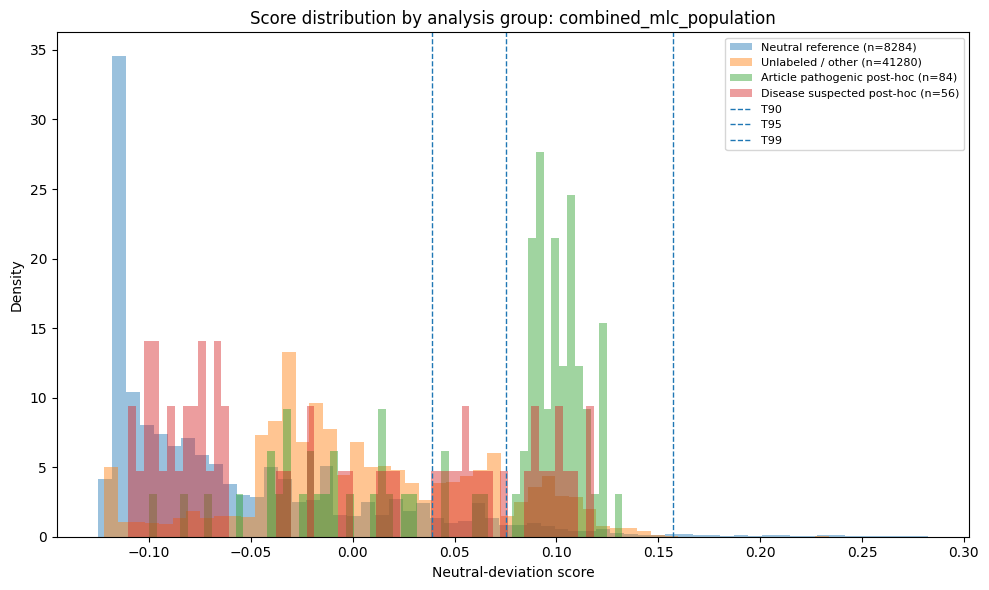

In [23]:
plot_score_distribution(scored, threshold_df, "combined_mlc_population")

In [24]:
def plot_score_boxplot(scored, threshold_df, set_name):
    score_col = f"{set_name}_deviation_score"

    data = []
    labels = []

    for group in analysis_group_order:
        subset = scored.loc[
            scored["analysis_group"] == group,
            score_col
        ].dropna()

        if len(subset) == 0:
            continue

        data.append(subset.values)
        labels.append(analysis_group_labels[group])

    plt.figure(figsize=(10, 6))

    plt.boxplot(
        data,
        labels=labels,
        showfliers=False,
    )

    for threshold_name in ["T90", "T95", "T99"]:
        threshold_value = threshold_df.loc[
            (threshold_df["score_name"] == set_name)
            & (threshold_df["threshold_name"] == threshold_name),
            "threshold_value"
        ].iloc[0]

        plt.axhline(
            threshold_value,
            linestyle="--",
            linewidth=1,
            label=threshold_name,
        )

    plt.ylabel("Neutral-deviation score")
    plt.title(f"Score distribution summary: {set_name}")
    plt.xticks(rotation=30, ha="right")
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

/var/folders/zp/hykk29rd2lndslkkjgkzfb640000gn/T/ipykernel_8467/3866398826.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


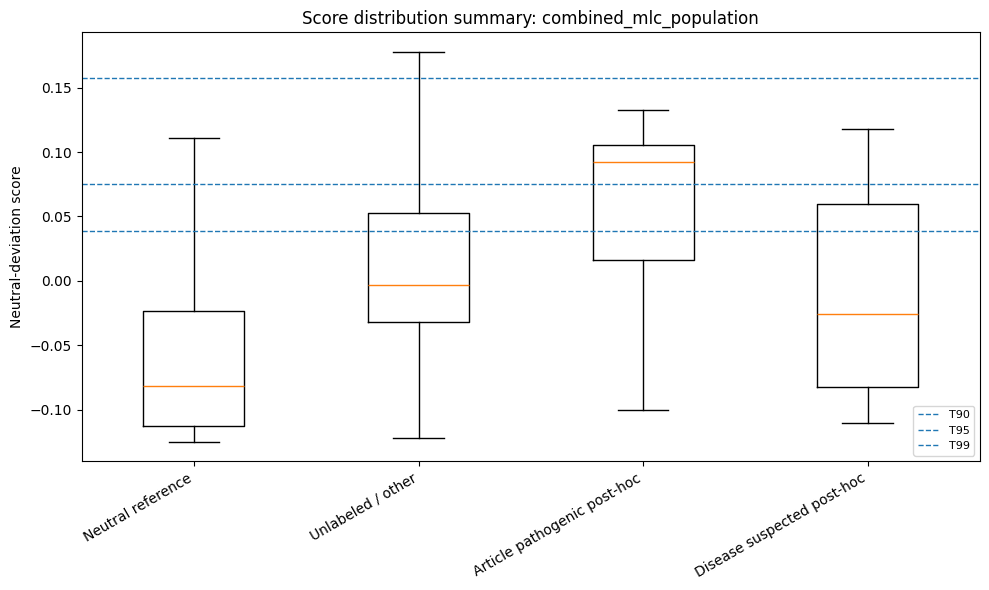

In [25]:
plot_score_boxplot(scored, threshold_df, "combined_mlc_population")

In [26]:
def plot_fraction_above_threshold(enrichment_df, set_name, threshold_name):
    plot_df = enrichment_df[
        (enrichment_df["score_name"] == set_name)
        & (enrichment_df["threshold_name"] == threshold_name)
    ].copy()

    plot_df["group_label"] = plot_df["analysis_group"].map(analysis_group_labels)

    plot_df = (
        plot_df
        .set_index("analysis_group")
        .loc[analysis_group_order]
        .reset_index()
    )

    x = np.arange(plot_df.shape[0])
    y = plot_df["fraction_above_threshold"].values

    plt.figure(figsize=(9, 5))
    plt.bar(x, y)

    plt.axhline(
        threshold_expected_fraction[threshold_name],
        linestyle="--",
        linewidth=1,
        label=f"Neutral reference expectation: {threshold_name}",
    )

    plt.xticks(
        x,
        plot_df["group_label"],
        rotation=30,
        ha="right",
    )

    plt.ylabel("Fraction above threshold")
    plt.title(f"Fraction above {threshold_name}: {set_name}")
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

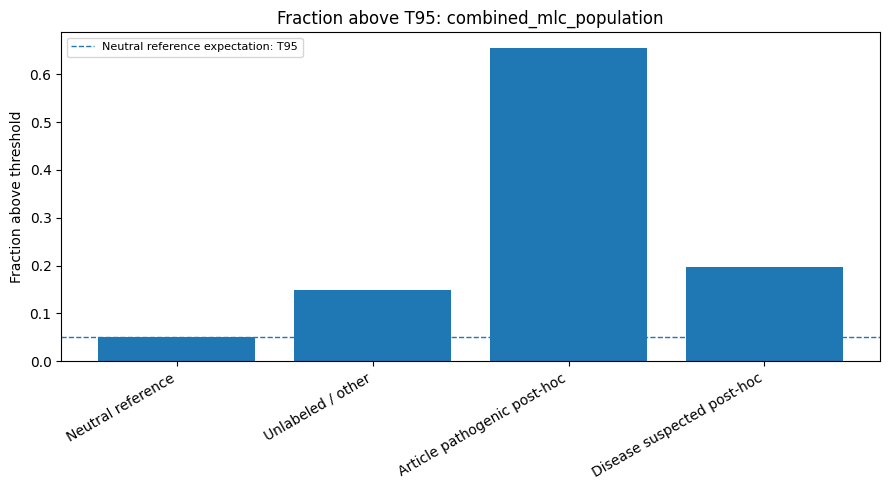

In [27]:
plot_fraction_above_threshold(
    enrichment_df,
    set_name="combined_mlc_population",
    threshold_name="T95",
)

In [28]:
def plot_mlc_vs_combined_score(scored):
    x_col = "mlc_score"
    y_col = "combined_mlc_population_deviation_score"

    if x_col not in scored.columns:
        raise ValueError(f"Missing column: {x_col}")

    if y_col not in scored.columns:
        raise ValueError(f"Missing column: {y_col}")

    plt.figure(figsize=(8, 6))

    for group in analysis_group_order:
        subset = scored[scored["analysis_group"] == group]

        if subset.shape[0] == 0:
            continue

        if group == "unlabeled_or_other" and subset.shape[0] > 5000:
            subset = subset.sample(
                n=5000,
                random_state=42,
            )

        plt.scatter(
            subset[x_col],
            subset[y_col],
            s=8,
            alpha=0.5,
            label=analysis_group_labels[group],
        )

    plt.xlabel("mlc_score")
    plt.ylabel("Combined neutral-deviation score")
    plt.title("mlc_score vs combined neutral-deviation score")
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

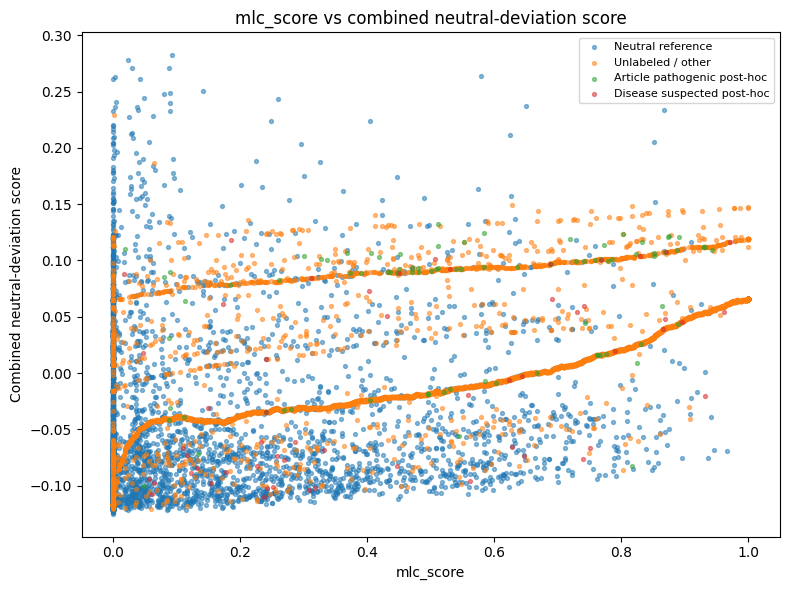

In [29]:
plot_mlc_vs_combined_score(scored)